# **Aircraft Classification**

*Image Processing and Computer Vision — Assignment Module #2*

Group members:

- Annalisa Poluzzi
- Jacopo Francesco Amoretti
- Alessia Andrea Toma

The goal of this assignment is to implement a neural network that classifies images of 100 aircraft model variants from the [Fine-Grained Visual Classification of Aircraft (**FGVC-Aircraft**) dataset](https://www.robots.ox.ac.uk/~vgg/data/fgvc-aircraft/).

In Part 1, we will design and train a custom Convolutional Neural Network (CNN) from scratch and perform an ablation study to validate our design choices.

## 1. Setup and Environment

First, we ensure all necessary libraries are installed. Then, we import them and configure our computation device to utilize a GPU if one is available, which significantly speeds up training.

In [ ]:
# Install the required libraries (useful if running on Google Colab or a fresh environment)
!pip install torch torchvision matplotlib numpy

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# Check for GPU availability
# Hardware check for Apple Silicon (MPS), NVIDIA (CUDA), or fallback (CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

## 2. Dataset Preparation

We download the **FGVC-Aircraft** dataset directly using PyTorch's `torchvision.datasets`.

Since we are building a model from scratch in Part 1, it is crucial to apply **Data Augmentation** to our training set. Techniques like random cropping, horizontal flipping, and slight rotations help prevent overfitting and improve the model's ability to generalize to unseen data. The test set only requires standard resizing and normalization.

In [ ]:
# Define standard image size for our custom network
IMG_SIZE = 224

# Training transformations with Data Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    # Normalize using standard ImageNet mean and std deviation values
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Testing transformations (No Data Augmentation, strictly evaluation)
test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create a data directory
os.makedirs('./data', exist_ok=True)

# Download and load the training/validation dataset
print("Downloading and loading the training/validation dataset...")
train_dataset = datasets.FGVCAircraft(
    root='./data',
    split='trainval',
    annotation_level='variant',
    transform=train_transforms,
    download=True
)

# Download and load the test dataset
print("Downloading and loading the test dataset...")
test_dataset = datasets.FGVCAircraft(
    root='./data',
    split='test',
    annotation_level='variant',
    transform=test_transforms,
    download=True
)

# Define DataLoaders to iterate through the data in batches
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("\n--- Dataset Info ---")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Number of training images: {len(train_dataset)}")
print(f"Number of test images: {len(test_dataset)}")


--- Dataset Info ---
Number of classes: 100
Number of training images: 6667
Number of test images: 3333


## 3. Custom CNN Architecture

For Part 1 of the assignment, we need to design a neural network from scratch without using pre-trained models.

We will build a simple but effective Convolutional Neural Network (CNN) using standard PyTorch layers:
* **Convolutional Layers (`nn.Conv2d`)**: To extract features like edges and shapes.
* **Batch Normalization (`nn.BatchNorm2d`)**: To stabilize and speed up training.
* **Max Pooling (`nn.MaxPool2d`)**: To reduce spatial dimensions.
* **Fully Connected Layers (`nn.Linear`)**: To classify the extracted features into the 100 aircraft variants.
* **Dropout (`nn.Dropout`)**: To randomly zero some elements to prevent overfitting during training.

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=100):
        super(CustomCNN, self).__init__()

        # Feature Extractor: Convolutional Blocks
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Adding one more block to extract deeper features
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Classifier: Global Average Pooling + Fully Connected
        self.classifier = nn.Sequential(
            # This magically reduces any (Channels, H, W) to (Channels, 1, 1)
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CustomCNN(num_classes=100).to(device)
print(model)

# Instantiate the model and move it to the selected device (MPS/GPU/CPU)
model = CustomCNN(num_classes=100).to(device)

# Print the model architecture to verify it
print(model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

## 4. Model Training

With our architecture defined, we need to specify how the model learns from its mistakes:
* **Loss Function**: `CrossEntropyLoss` is the standard for multi-class classification problems. It calculates the difference between the model's predictions and the actual labels.
* **Optimizer**: We use `Adam` (Adaptive Moment Estimation) to update the network's weights based on the calculated loss.

The training loop iterates through the dataset for a set number of `epochs`. In each iteration, it performs a forward pass (making predictions), calculates the loss, performs a backward pass (calculating gradients), and updates the weights.

In [ ]:
# Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

# Number of epochs
num_epochs = 20

print(f"Starting training on device: {device}")
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train() # Set the model to training mode (enables Dropout and BatchNorm)
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        # Move data to the active device (MPS)
        images, labels = images.to(device), labels.to(device)

        # 1. Zero the parameter gradients to prevent accumulation
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 3. Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Track statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

Starting training on device: mps
Epoch [1/20] | Loss: 4.7802 | Accuracy: 1.74%
Epoch [2/20] | Loss: 4.5289 | Accuracy: 2.58%
Epoch [3/20] | Loss: 4.3213 | Accuracy: 3.63%
Epoch [4/20] | Loss: 4.1353 | Accuracy: 5.41%
Epoch [5/20] | Loss: 3.9107 | Accuracy: 6.73%
Epoch [6/20] | Loss: 3.6273 | Accuracy: 10.69%
Epoch [7/20] | Loss: 3.3759 | Accuracy: 13.95%
Epoch [8/20] | Loss: 3.1758 | Accuracy: 17.46%
Epoch [9/20] | Loss: 3.0111 | Accuracy: 20.20%
Epoch [10/20] | Loss: 2.8320 | Accuracy: 23.65%
Epoch [11/20] | Loss: 2.6490 | Accuracy: 28.15%
Epoch [12/20] | Loss: 2.5113 | Accuracy: 31.47%
Epoch [13/20] | Loss: 2.3397 | Accuracy: 35.70%
Epoch [14/20] | Loss: 2.2022 | Accuracy: 38.80%
Epoch [15/20] | Loss: 2.0716 | Accuracy: 41.31%
Epoch [16/20] | Loss: 1.9441 | Accuracy: 44.41%
Epoch [17/20] | Loss: 1.8047 | Accuracy: 47.97%
Epoch [18/20] | Loss: 1.7255 | Accuracy: 49.98%
Epoch [19/20] | Loss: 1.6170 | Accuracy: 53.53%
Epoch [20/20] | Loss: 1.5445 | Accuracy: 54.45%


## 5. Evaluation

After training, we must evaluate the model on the unseen `test_dataset` to determine its true performance. The target for this custom network is ~50% accuracy.

During evaluation, we use `model.eval()` to disable Dropout and adjust Batch Normalization to evaluation mode. We also use `torch.no_grad()` to disable gradient tracking, which saves memory and computation power.

In [ ]:
def evaluate_model(model, dataloader):
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0

    # Disable gradient calculation for inference
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

print("Evaluating baseline custom model on the test set...")
baseline_test_accuracy = evaluate_model(model, test_loader)
print(f"Final Test Accuracy (Baseline CustomCNN): {baseline_test_accuracy:.2f}%")

# Save the model weights for future reference
torch.save(model.state_dict(), "custom_cnn_baseline.pth")
print("Model saved to custom_cnn_baseline.pth")

Evaluating baseline custom model on the test set...
Final Test Accuracy (Baseline CustomCNN): 49.05%
Model saved to custom_cnn_baseline.pth


## 6. Visualizing Training Results

To properly validate our model and monitor the network's learning process, we will visualize the training loss and accuracy over the epochs. This directly fulfills the assignment's requirement to show our results with clear plots.

By graphing these metrics, we can verify that the model is continuously converging (loss is decreasing) and check for any early signs of overfitting before moving on to our ablation study.

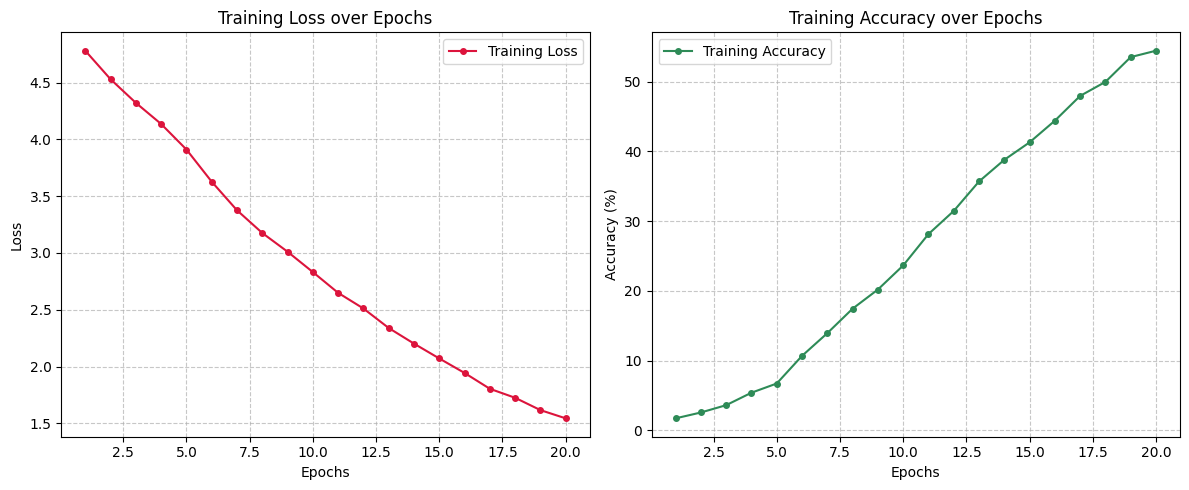

In [ ]:
import matplotlib.pyplot as plt

# Creiamo una figura con due grafici affiancati
plt.figure(figsize=(12, 5))

# Grafico 1: Curva di Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='crimson', marker='o', markersize=4)
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Grafico 2: Curva di Accuratezza
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy', color='seagreen', marker='o', markersize=4)
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

## 7. Ablation Study

The baseline `CustomCNN` reached approximately 50% test accuracy , meeting the assignment's target. This section validates the design choices behind that model through an **ablation study**.

The principle: take the full model and, one component at a time, remove a single design choice, retrain from scratch under identical conditions (20 epochs, Adam, lr=0.003), and measure the change in test accuracy. If removing a component lowers accuracy, that component contributed positively.

Within this ablation, the full model is retrained under the same conditions to serve as the internal reference point against which each ablated variant is compared. This keeps the comparison fair: every variant shares the same training run and differs from the reference by exactly one factor.

Four components are ablated: **Batch Normalization**, **Data Augmentation**, **Dropout**, and **Network Depth (5th conv block)**.

A single configurable network, `AblationCNN`, is used, whose components can be toggled on/off. With all switches on, it is identical to the baseline `CustomCNN`.

### The configurable network

To ensure each ablated variant differs from the baseline by exactly one factor, a single configurable network is defined. Boolean switches (`use_batchnorm`, `use_dropout`, `use_deep_block`) turn individual components on or off. With all switches set to `True`, this network is identical to the original `CustomCNN`.

In [ ]:
# Configurable CNN for the ablation study.
# With all switches True, this is identical to the baseline CustomCNN.

class AblationCNN(nn.Module):
    def __init__(self, num_classes=100,
                 use_batchnorm=True,
                 use_dropout=True,
                 use_deep_block=True):
        super(AblationCNN, self).__init__()

        def conv_block(in_ch, out_ch):
            layers = [nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)]
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            return layers

        feature_layers = []
        feature_layers += conv_block(3, 32)
        feature_layers += conv_block(32, 64)
        feature_layers += conv_block(64, 128)
        feature_layers += conv_block(128, 256)

        if use_deep_block:
            feature_layers += conv_block(256, 512)
            final_channels = 512
        else:
            final_channels = 256

        self.features = nn.Sequential(*feature_layers)

        classifier_layers = [
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
        ]
        if use_dropout:
            classifier_layers.append(nn.Dropout(p=0.5))
        classifier_layers.append(nn.Linear(final_channels, num_classes))

        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Data loader without augmentation

The data augmentation ablation cannot be toggled inside the model, since augmentation lives in the data pipeline. A separate training loader is therefore built using the same simple transforms as the test set (resize + center crop, no random flips/rotations/crops), so this variant trains on non-augmented images.

In [ ]:
# For the "no data augmentation" experiment: a training loader that uses the
# SAME simple transforms as the test set (no random crop/flip/rotation).

train_transforms_noaug = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_noaug = datasets.FGVCAircraft(
    root='./data', split='trainval', annotation_level='variant',
    transform=train_transforms_noaug, download=False
)
train_loader_noaug = DataLoader(train_dataset_noaug, batch_size=batch_size,
                                shuffle=True, num_workers=2)

### Reusable training function

A single training function is defined and reused for every experiment, guaranteeing that all variants are trained under identical conditions (same epochs, optimizer, and learning rate). It also records the per-epoch training accuracy, which will be useful to inspect overfitting in the augmentation ablation.

In [ ]:
# Reusable training function. Returns the training-accuracy history too,
# so train-vs-test (overfitting) can be shown later.

def train_model(model, loader, num_epochs=20, lr=0.003):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_acc_history = []
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        epoch_acc = 100 * correct / total
        train_acc_history.append(epoch_acc)
        print(f"  Epoch [{epoch+1}/{num_epochs}] | Loss: {running_loss/total:.4f} | Train Acc: {epoch_acc:.2f}%")
    return model, train_acc_history

### Running the ablation

The five configurations are defined below: the full model plus four variants, each removing one component. Each configuration is trained from scratch and evaluated on the test set. This is the core of the ablation study.

In [ ]:
# The five configurations: baseline + 4 single removals.

experiments = [
    {"name": "Full model (baseline)",  "config": {}, "loader": train_loader},
    {"name": "No Batch Normalization", "config": {"use_batchnorm": False}, "loader": train_loader},
    {"name": "No Data Augmentation",   "config": {}, "loader": train_loader_noaug},
    {"name": "No Dropout",             "config": {"use_dropout": False}, "loader": train_loader},
    {"name": "No 5th Conv Block",      "config": {"use_deep_block": False}, "loader": train_loader},
]

ablation_results = {}
ablation_train_hist = {}

for exp in experiments:
    print(f"\n===== Training: {exp['name']} =====")
    model_variant = AblationCNN(num_classes=100, **exp["config"])
    model_variant, hist = train_model(model_variant, exp["loader"], num_epochs=20, lr=0.003)
    acc = evaluate_model(model_variant, test_loader)
    ablation_results[exp["name"]] = acc
    ablation_train_hist[exp["name"]] = hist
    print(f">>> Test Accuracy for '{exp['name']}': {acc:.2f}%")

print("\n\n===== ABLATION COMPLETE =====")
for name, acc in ablation_results.items():
    print(f"{name}: {acc:.2f}%")


===== Training: Full model (baseline) =====
  Epoch [1/20] | Loss: 4.8021 | Train Acc: 1.51%
  Epoch [2/20] | Loss: 4.5490 | Train Acc: 2.91%
  Epoch [3/20] | Loss: 4.3786 | Train Acc: 4.05%
  Epoch [4/20] | Loss: 4.0779 | Train Acc: 6.27%
  Epoch [5/20] | Loss: 3.7578 | Train Acc: 9.33%
  Epoch [6/20] | Loss: 3.5398 | Train Acc: 11.35%
  Epoch [7/20] | Loss: 3.3739 | Train Acc: 14.17%
  Epoch [8/20] | Loss: 3.1959 | Train Acc: 16.95%
  Epoch [9/20] | Loss: 3.0354 | Train Acc: 20.07%
  Epoch [10/20] | Loss: 2.8987 | Train Acc: 23.01%
  Epoch [11/20] | Loss: 2.7160 | Train Acc: 26.73%
  Epoch [12/20] | Loss: 2.5705 | Train Acc: 29.82%
  Epoch [13/20] | Loss: 2.4620 | Train Acc: 31.89%
  Epoch [14/20] | Loss: 2.3294 | Train Acc: 35.83%
  Epoch [15/20] | Loss: 2.1922 | Train Acc: 39.18%
  Epoch [16/20] | Loss: 2.0768 | Train Acc: 42.04%
  Epoch [17/20] | Loss: 1.9638 | Train Acc: 44.52%
  Epoch [18/20] | Loss: 1.8580 | Train Acc: 47.70%
  Epoch [19/20] | Loss: 1.7568 | Train Acc: 49.39%


### Results

The results are summarized in a table (with the accuracy drop relative to the full model) and a bar chart. A larger drop indicates a component that contributed more to the final performance.

Configuration                |  Test Acc |  Delta vs baseline
--------------------------------------------------------------
Full model (baseline)        |   48.60 % |                  -
No Batch Normalization       |    0.99 % |           -47.61 %
No Data Augmentation         |   51.67 % |            +3.06 %
No Dropout                   |   51.46 % |            +2.85 %
No 5th Conv Block            |   32.94 % |           -15.66 %


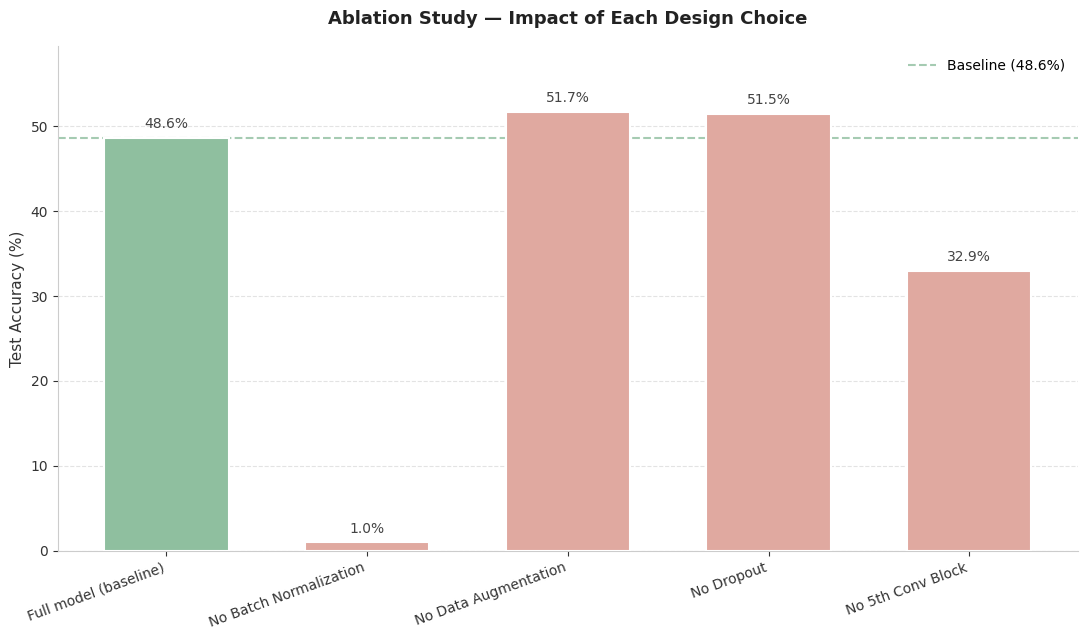

In [ ]:
import matplotlib.pyplot as plt

names = list(ablation_results.keys())
accuracies = list(ablation_results.values())
baseline_acc = ablation_results["Full model (baseline)"]

print(f"{'Configuration':<28} | {'Test Acc':>9} | {'Delta vs baseline':>18}")
print("-" * 62)
for name, acc in ablation_results.items():
    delta = acc - baseline_acc
    delta_str = "-" if name == "Full model (baseline)" else f"{delta:+.2f} %"
    print(f"{name:<28} | {acc:>7.2f} % | {delta_str:>18}")

plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(figsize=(11, 6.5))

baseline_color = '#8FBF9F'
ablation_color = '#E0A9A0'
colors = [baseline_color] + [ablation_color] * 4

bars = ax.bar(names, accuracies, color=colors, width=0.62,
              edgecolor='white', linewidth=1.5, zorder=3)

ax.axhline(baseline_acc, color=baseline_color, linestyle='--',
           linewidth=1.5, alpha=0.8, zorder=2,
           label=f'Baseline ({baseline_acc:.1f}%)')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{acc:.1f}%', ha='center', va='bottom',
            fontsize=10, color='#444444', fontweight='medium')

ax.set_ylabel('Test Accuracy (%)', fontsize=11, color='#333333')
ax.set_title('Ablation Study — Impact of Each Design Choice',
             fontsize=13, color='#222222', pad=16, fontweight='semibold')
ax.set_ylim(0, max(accuracies) * 1.15)
ax.legend(frameon=False, fontsize=10, loc='upper right')

ax.yaxis.grid(True, linestyle='--', alpha=0.35, zorder=0)
ax.set_axisbelow(True)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

ax.tick_params(axis='x', rotation=20, labelsize=10, colors='#333333')
ax.tick_params(axis='y', labelsize=10, colors='#333333')
plt.setp(ax.get_xticklabels(), ha='right')

plt.tight_layout()
plt.show()

**Batch Normalization (−47.61%).** Removing batch normalization is by far the most impactful ablation: test accuracy collapses from 48.6% to 0.99%, i.e. random guessing over 100 classes. This confirms that batch normalization is essential to our architecture. By normalizing the activations at each layer, it keeps gradients well-conditioned and allows stable training even with the relatively high learning rate (0.003) used here. Without it, at this learning rate the optimization diverges and the network fails to learn altogether. This is the strongest evidence in the study that a design choice was justified.

**Data Augmentation (+3.06%).** Removing data augmentation slightly *increases* test accuracy (from 48.6% to 51.7%). At first glance counterintuitive, this is explained by the short training budget: data augmentation (random crops, flips, rotations) makes the training task harder and typically requires more epochs to pay off, as the network must learn to cope with the added variability. Within only 20 epochs, augmentation acts more as an obstacle to convergence than as an effective regularizer. We would expect its benefit to emerge with longer training, where its role in preventing overfitting becomes relevant. This is a useful illustration that the value of a component depends on the training regime.

**Dropout (+2.85%).** Similarly, removing dropout slightly improves test accuracy. Dropout is a regularizer designed to combat overfitting by randomly deactivating units during training. However, our baseline shows only a small gap between training and test accuracy, indicating that overfitting is not the limiting factor in this short-training regime. When a model is not overfitting, dropout mainly slows down convergence by removing capacity at each step, which explains the small drop in performance when it is active. As with augmentation, we would expect dropout to become beneficial with longer training or a higher-capacity model.

**Network Depth — 5th Convolutional Block (−15.66%).** Removing the fifth convolutional block causes a substantial drop, from 48.6% to 32.9%. The deeper block increases the network's receptive field and its capacity to represent complex, high-level features — which is particularly important in a fine-grained task such as distinguishing 100 visually similar aircraft variants. Its removal confirms that the extra depth contributes meaningfully to the model's discriminative power, and justifies its inclusion in the architecture.

### Ablation summary

The ablation study reveals that not all components contribute equally, and that their value is tied to the training regime:

- **Batch normalization** is indispensable: without it the network does not train at all (−47.6%).
- **Network depth** (the 5th conv block) provides a clear, substantial benefit (−15.7%), consistent with the demands of a fine-grained classification task.
- **Data augmentation** and **dropout**, both regularizers, do *not* help within this short 20-epoch budget — and slightly hurt — because the model is not in an overfitting regime where they would pay off. Their inclusion remains a sound design choice for longer training schedules, where they are expected to improve generalization.

Overall, the two components that define the model's ability to learn and represent features (batch normalization and depth) are strongly validated, while the two regularizers highlight that the usefulness of a design choice is inseparable from the training conditions under which it is evaluated.

# Part 2: Fine-tune an Existing Network

In this part of the assignment, we transition from building a network from scratch to utilizing **Transfer Learning**. We leverage a **ResNet-18** architecture pretrained on the ImageNet-1K dataset provided by PyTorch.

## Part 2A: Baseline Fine-Tuning with Identical Hyperparameters

As specified by the assignment requirements, we will first fine-tune the ResNet-18 model using the exact same training hyperparameters that led to our best custom model in Part 1:
* **Optimizer:** Adam
* **Learning Rate (lr):** 0.003
* **Batch Size:** 32
* **Epochs:** 20
* **Loss Function:** Cross-Entropy Loss

To adapt the pretrained model to the FGVC-Aircraft dataset, we will replace the final fully connected layer (`model.fc`) to output predictions for our 100 unique aircraft variants instead of the original 1000 ImageNet classes.

In [ ]:
import torchvision.models as models
from torchvision.models import ResNet18_Weights

print(f"Loading pretrained ResNet-18 weights... Using device: {device}")

# 1. Load the pretrained ResNet-18 model
resnet_model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# 2. FREEZE THE BACKBONE (Crucial step for Part 2A)
# We freeze all convolutional layers so their pretrained ImageNet weights
# are not destroyed by our potentially high learning rate (0.003).
for param in resnet_model.parameters():
    param.requires_grad = False

# 3. Replace the final linear layer (Classifier)
# By default, new layers have requires_grad=True, so only this layer will be trained.
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 100)

# 4. Move the model to the device
resnet_model = resnet_model.to(device)

print("ResNet-18 structure adapted successfully. Backbone frozen. Only the FC layer will be trained.")

Loading pretrained ResNet-18 weights... Using device: mps
ResNet-18 structure adapted successfully. Backbone frozen. Only the FC layer will be trained.


In [ ]:
# Re-define the loss criterion and the optimizer with identical hyperparameters from Part 1
criterion_2a = nn.CrossEntropyLoss()

# Note: We only pass the parameters that require gradients (the new fc layer) to the optimizer
optimizer_2a = optim.Adam(resnet_model.fc.parameters(), lr=0.003)

num_epochs_2a = 20
resnet_train_losses = []
resnet_train_accuracies = []

print("Starting ResNet-18 Feature Extraction (Part 2A)...")

for epoch in range(num_epochs_2a):
    resnet_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_2a.zero_grad()
        outputs = resnet_model(images)
        loss = criterion_2a(outputs, labels)
        loss.backward()
        optimizer_2a.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = 100 * correct / total

    resnet_train_losses.append(epoch_loss)
    resnet_train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs_2a}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

Starting ResNet-18 Feature Extraction (Part 2A)...
Epoch [1/20] | Loss: 4.3521 | Accuracy: 9.57%
Epoch [2/20] | Loss: 3.2971 | Accuracy: 23.89%
Epoch [3/20] | Loss: 2.9275 | Accuracy: 29.50%
Epoch [4/20] | Loss: 2.7048 | Accuracy: 33.46%
Epoch [5/20] | Loss: 2.5678 | Accuracy: 35.62%
Epoch [6/20] | Loss: 2.4591 | Accuracy: 37.75%
Epoch [7/20] | Loss: 2.4181 | Accuracy: 39.15%
Epoch [8/20] | Loss: 2.2958 | Accuracy: 40.80%
Epoch [9/20] | Loss: 2.2801 | Accuracy: 40.80%
Epoch [10/20] | Loss: 2.2592 | Accuracy: 42.39%
Epoch [11/20] | Loss: 2.1815 | Accuracy: 43.45%
Epoch [12/20] | Loss: 2.1771 | Accuracy: 43.72%
Epoch [13/20] | Loss: 2.1316 | Accuracy: 45.34%
Epoch [14/20] | Loss: 2.1050 | Accuracy: 45.82%
Epoch [15/20] | Loss: 2.0744 | Accuracy: 45.06%
Epoch [16/20] | Loss: 2.0650 | Accuracy: 46.50%
Epoch [17/20] | Loss: 2.0541 | Accuracy: 46.24%
Epoch [18/20] | Loss: 2.0136 | Accuracy: 47.22%
Epoch [19/20] | Loss: 1.9729 | Accuracy: 47.83%
Epoch [20/20] | Loss: 2.0296 | Accuracy: 47.07%

In [ ]:
print("Evaluating the fine-tuned ResNet-18 baseline on the test set...")

# Use the evaluation function we created in Part 1
resnet_baseline_test_accuracy = evaluate_model(resnet_model, test_loader)

print(f"\nFinal Test Accuracy (ResNet-18 Part 2A): {resnet_baseline_test_accuracy:.2f}%")

# Save the model weights
torch.save(resnet_model.state_dict(), "resnet18_fine_tuned_2a.pth")
print("Model saved to resnet18_fine_tuned_2a.pth")

Evaluating the fine-tuned ResNet-18 baseline on the test set...

Final Test Accuracy (ResNet-18 Part 2A): 33.66%
Model saved to resnet18_fine_tuned_2a.pth


## Part 2B: Fine-tuning with improved hyperparameters

Part 2A froze the entire ResNet-18 backbone and trained only the final fully-connected layer, reaching **33.66%** test accuracy. This is a striking result: the pretrained ResNet-18 performed considerably worse than the custom CNN trained from scratch (~50%). The explanation is not a poor choice of learning rate or epoch count, but a structural one. With the backbone frozen, the network can only reuse the generic features learned on ImageNet — edges, textures, coarse object shapes. Those features separate a car from a dog, but they are far too generic to separate a Boeing 737-300 from a Boeing 737-400. In a fine-grained task, discrimination depends on subtle structural details that a frozen backbone was never trained to represent.

Part 2B therefore changes three hyperparameters, each addressing a specific weakness observed above.

**1. Unfreezing the whole backbone.** All layers are made trainable, so the network can reshape its internal representations around the aircraft domain rather than reusing ImageNet features unchanged. This is the transition from *feature extraction* to *full fine-tuning*, and it is the single change that addresses the root cause of the 33.66%.

**2. Lowering the learning rate from 3e-3 to 1e-4.** This change is inseparable from the previous one. Once the backbone is unfrozen, its weights are no longer protected: a large learning rate would overwrite the very ImageNet knowledge that makes transfer learning worthwhile (*catastrophic forgetting*). A learning rate two orders of magnitude smaller adapts those weights gently instead of destroying them. Unfreezing without lowering the learning rate would likely perform worse than not unfreezing at all.

**3. Adding a StepLR scheduler.** The learning rate is divided by 10 every 7 epochs, allowing larger corrections early in training and progressively finer refinements as the model approaches convergence.

The epoch budget is raised from 20 to 25, since roughly 11 million parameters are now being adapted rather than the ~51 thousand of the final layer alone.


In [ ]:
from torchvision.models import resnet18, ResNet18_Weights
from torch.optim.lr_scheduler import StepLR

resnet_ft = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

for param in resnet_ft.parameters():
    param.requires_grad = True

num_ftrs = resnet_ft.fc.in_features
resnet_ft.fc = nn.Linear(num_ftrs, 100)
resnet_ft = resnet_ft.to(device)

criterion_ft = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(resnet_ft.parameters(), lr=0.0001)
scheduler_ft = StepLR(optimizer_ft, step_size=7, gamma=0.1)

num_epochs_ft = 25

train_losses_ft = []
train_accs_ft = []
test_accs_ft = []

for epoch in range(num_epochs_ft):
    resnet_ft.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_ft.zero_grad()
        outputs = resnet_ft(images)
        loss = criterion_ft(outputs, labels)
        loss.backward()
        optimizer_ft.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    scheduler_ft.step()

    epoch_loss = running_loss / total
    epoch_train_acc = 100 * correct / total

    resnet_ft.eval()
    correct_t, total_t = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet_ft(images)
            _, predicted = torch.max(outputs.data, 1)
            total_t += labels.size(0)
            correct_t += (predicted == labels).sum().item()
    epoch_test_acc = 100 * correct_t / total_t

    train_losses_ft.append(epoch_loss)
    train_accs_ft.append(epoch_train_acc)
    test_accs_ft.append(epoch_test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs_ft}] | LR: {scheduler_ft.get_last_lr()[0]:.6f} | "
          f"Loss: {epoch_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Test Acc: {epoch_test_acc:.2f}%")

final_acc_ft = test_accs_ft[-1]
best_acc_ft = max(test_accs_ft)
print(f"\nFinal Test Accuracy (Fine-tuned ResNet-18): {final_acc_ft:.2f}%")
print(f"Best Test Accuracy reached: {best_acc_ft:.2f}%")

Epoch [1/25] | LR: 0.000100 | Loss: 3.7289 | Train Acc: 18.24% | Test Acc: 36.00%
Epoch [2/25] | LR: 0.000100 | Loss: 2.1936 | Train Acc: 50.98% | Test Acc: 54.79%
Epoch [3/25] | LR: 0.000100 | Loss: 1.4669 | Train Acc: 65.85% | Test Acc: 66.13%
Epoch [4/25] | LR: 0.000100 | Loss: 1.0316 | Train Acc: 75.25% | Test Acc: 69.28%
Epoch [5/25] | LR: 0.000100 | Loss: 0.7731 | Train Acc: 82.06% | Test Acc: 70.75%
Epoch [6/25] | LR: 0.000100 | Loss: 0.5987 | Train Acc: 85.71% | Test Acc: 73.66%
Epoch [7/25] | LR: 0.000010 | Loss: 0.4513 | Train Acc: 89.98% | Test Acc: 75.19%
Epoch [8/25] | LR: 0.000010 | Loss: 0.2980 | Train Acc: 94.71% | Test Acc: 78.73%
Epoch [9/25] | LR: 0.000010 | Loss: 0.2530 | Train Acc: 96.21% | Test Acc: 78.64%
Epoch [10/25] | LR: 0.000010 | Loss: 0.2392 | Train Acc: 96.34% | Test Acc: 78.91%
Epoch [11/25] | LR: 0.000010 | Loss: 0.2239 | Train Acc: 96.78% | Test Acc: 79.00%
Epoch [12/25] | LR: 0.000010 | Loss: 0.2061 | Train Acc: 97.47% | Test Acc: 79.48%
Epoch [13/25]

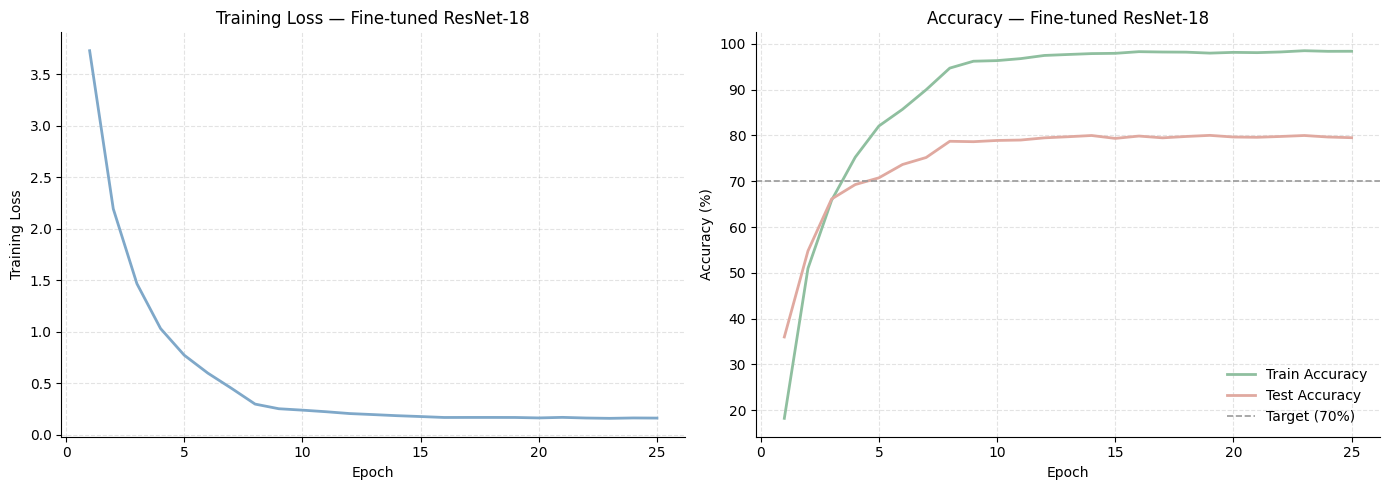

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, num_epochs_ft + 1)

axes[0].plot(epochs_range, train_losses_ft, color='#7FA8C9', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss — Fine-tuned ResNet-18')
axes[0].grid(True, linestyle='--', alpha=0.35)
axes[0].set_axisbelow(True)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

axes[1].plot(epochs_range, train_accs_ft, color='#8FBF9F', linewidth=2, label='Train Accuracy')
axes[1].plot(epochs_range, test_accs_ft, color='#E0A9A0', linewidth=2, label='Test Accuracy')
axes[1].axhline(70, color='#999999', linestyle='--', linewidth=1.2, label='Target (70%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy — Fine-tuned ResNet-18')
axes[1].legend(frameon=False)
axes[1].grid(True, linestyle='--', alpha=0.35)
axes[1].set_axisbelow(True)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Results and analysis

Full fine-tuning raises test accuracy from **33.66%** to **79.51%**, with a peak of **80.02%** at epoch 19 — well above the ~70% target. The magnitude of the jump (+46 points) confirms that the limitation in Part 2A was structural rather than a matter of hyperparameter tuning: no learning rate applied to a single trainable layer could have recovered this gap.

**Convergence.** The 70% target is crossed at epoch 5, and test accuracy plateaus around epoch 11–13, oscillating between 79% and 80% thereafter. The loss curve flattens at the same point. In hindsight, a budget of roughly 13 epochs would have sufficed; the final third of training contributes nothing to generalization.

**Overfitting.** The accuracy plot shows the two curves separating clearly. Up to epoch 3 they move together (65.85% train, 66.13% test), but from epoch 4 the gap widens monotonically, reaching almost 19 points by the end (98.38% train against 79.51% test). With ~11 million trainable parameters fitted on a dataset of this size, the network progressively memorizes the training images while learning nothing further about unseen ones. This is the expected cost of full fine-tuning on limited data, and it is now the factor limiting further improvement — not the learning rate, and not the depth of the model.

**Effect of the scheduler.** The learning rate drops at epochs 7, 14 and 21. Each drop visibly stabilizes the loss, but the benefit lands almost entirely on the training accuracy: immediately after the first reduction, training accuracy jumps from 89.98% to 96.21% in two epochs, while test accuracy moves from 75.19% to 78.64% and then stops. The scheduler is refining the fit to the training set more than it is improving generalization. This is a useful caution: a loss curve that flattens smoothly is not, by itself, evidence of a better model.

**Connection to the ablation study.** This result completes the picture opened by the ablation in Part 1. There, removing dropout and data augmentation *improved* test accuracy (+2.85% and +3.06%), a counterintuitive outcome explained by the absence of overfitting: within 20 epochs, the custom CNN never reached the regime in which regularizers become useful. Here, the opposite situation holds. The fine-tuned ResNet overfits heavily, and this is precisely the regime in which dropout and augmentation would earn their place. The two experiments are therefore not in contradiction — they are two points on the same curve. A regularizer is not intrinsically good or bad; its value depends entirely on whether the model is in a position to overfit in the first place.

**What we would try next.** Given the diagnosis above, the natural next steps target the train/test gap rather than the fit to the training data: early stopping around epoch 13, weight decay in the optimizer, or a more aggressive augmentation pipeline. Each of these trades training accuracy for generalization — exactly the trade the current model is failing to make.

### Overall conclusion

The two halves of this assignment converge on the same lesson from opposite directions.

The **custom CNN**, trained from scratch for 20 epochs, reaches ~50% test accuracy. Its ablation study shows that **batch normalization** and **network depth** are what allow it to learn at all: removing batch normalization collapses accuracy to 0.99%, i.e. random guessing across 100 classes, and removing the fifth convolutional block costs 15.66 points. **Dropout** and **data augmentation**, by contrast, slightly *reduce* accuracy — because a model that trains for only 20 epochs and never memorizes its training set has nothing for a regularizer to correct.

The **ResNet-18** reaches **79.51%**, but only once the backbone is unfrozen and the learning rate is lowered by two orders of magnitude to protect the pretrained weights. Frozen, it managed 33.66% — worse than the custom CNN, because generic ImageNet features cannot separate visually near-identical aircraft variants. Unfrozen, it overfits heavily: 98.38% on training data against 79.51% on test.

Placed side by side, the two experiments show that **no component of a network is good or bad in isolation**. Batch normalization was indispensable in one model and would be redundant to add to another. Dropout was a liability at 20 epochs on a small CNN and would be an asset on an overfitting ResNet. What determines the value of a design choice is the interaction between *model capacity*, *dataset size*, and *training budget* — which is precisely what an ablation study is designed to reveal, and why the same ablation run under a different training regime could well produce different conclusions.